In [1]:
%matplotlib widget
import ipywidgets as widgets
# from IPython.display import clear_output
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd
# import numpy as np
from tqdm.autonotebook import tqdm
from scipy.ndimage import gaussian_filter1d
# import h5py
# import copy
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

# import shlex

from diffSPH.simple import *
from util import *

# from waveEqn import WaveEquationState, waveEquation2
# from waveEqn import WaveSystem, waveSystemFunction

In [2]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
device = torch.device('cpu')
dtype = torch.float32
L = 1
dim = 2
nx = 32
dx = L/nx

kernel = KernelType.Wendland4
targetNeighbors = n_h_to_nH(4, dim)

domain = buildDomainDescription(L, dim, True, device, dtype)
domain.min = torch.zeros_like(domain.min)
domain.max = torch.ones_like(domain.max) * L

# particles = sampleOptimal(nx, domain, targetNeighbors, kernel, 0.2, 128, shiftScheme = 'delta')
# particles = sampleOptimal(nx, domain, targetNeighbors, kernel, 0.1, 128, shiftScheme = 'delta') 
particles = sampleOptimal(nx, domain, targetNeighbors, kernel, 0., 0, shiftScheme = 'delta') 
particlesLR = sampleOptimal(nx//2, domain, targetNeighbors, kernel, 0., 0, shiftScheme = 'delta')

particles = particles._replace(positions = particles.positions - dx/2)
particlesLR = particlesLR._replace(positions = particlesLR.positions - dx/4)    

config = {
    'domain': domain,
    'kernel': kernel,
    'targetNeighbors': targetNeighbors,
    'neighborhood':{
        'verletScale': 1.0,
        'computeHessian': True,
    }
}

config['gradientMode'] = GradientMode.Difference
config['laplacianMode'] = LaplacianMode.Brookshaw
config['supportScheme'] = SupportScheme.Gather
config['integrationScheme'] = IntegrationSchemeType.rungeKutta4

particleState = wcstateToState(particles)


0it [00:00, ?it/s]

0it [00:00, ?it/s]

In [3]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
import numpy as np
import jax
import exponax as ex
import matplotlib.pyplot as plt
import h5py

NUM_POINTS = nx

datafile = h5py.File(f"data_diffusedNoise_nx_{nx}.h5", "r")

u0 = np.array(datafile['u_0'])
jacobian = np.array(datafile['d'])
hessian = np.array(datafile['d2'])
patrician = np.array(datafile['d3'])

selected_seed = 0

values = [u0[selected_seed], jacobian[selected_seed], hessian[selected_seed], patrician[selected_seed]]
values = [torch.tensor(v, device=device, dtype=dtype).flatten(-2).T for v in values]

for v in values:
    print(v.shape)

torch.Size([1024, 1])
torch.Size([1024, 2])
torch.Size([1024, 2, 2])
torch.Size([1024, 2, 2, 2])


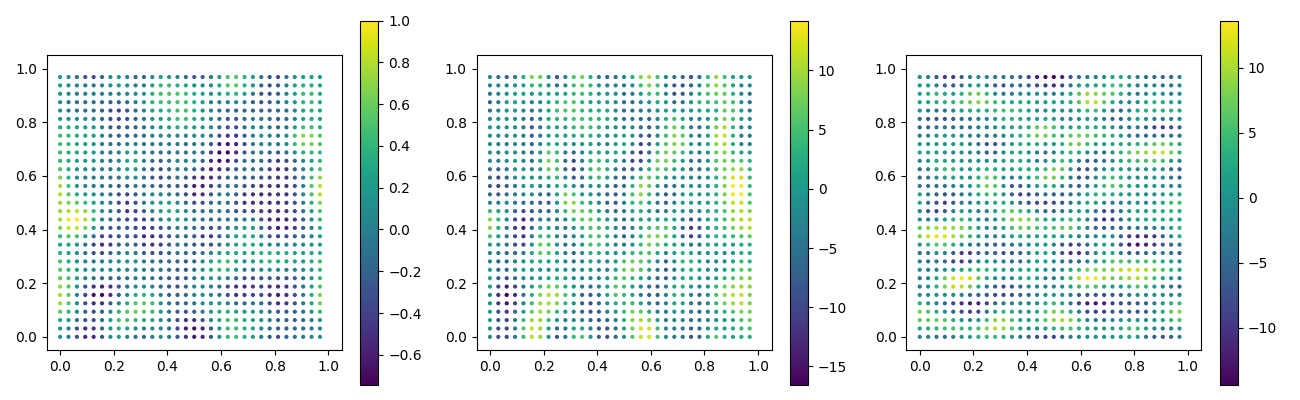

In [4]:
fig, axis = plt.subplots(1, 3, figsize=(13, 4), squeeze = False)

plot = visualizeParticles(fig, axis[0, 0],
  particles = particleState,
  domain = domain,
  quantity = values[0],
  which = 'fluid',
  mapping = '.x',
  cmap = 'viridis',
  visualizeBoth=False,
  kernel = kernel,
  plotDomain = False,
  gridVisualization=False, markerSize=4,
  streamLines = False)

plot = visualizeParticles(fig, axis[0, 1],
  particles = particleState,
  domain = domain,
  quantity = values[1],
  which = 'fluid',
  mapping = '.x',
  cmap = 'viridis',
  visualizeBoth=False,
  kernel = kernel,  
  plotDomain = False,
  gridVisualization=False, markerSize=4,
  streamLines = False)


plot = visualizeParticles(fig, axis[0, 2],
  particles = particleState,
  domain = domain,
  quantity = values[1],
  which = 'fluid',
  mapping = '.y',
  cmap = 'viridis',
  visualizeBoth=False,
  kernel = kernel,
  plotDomain = False,
  gridVisualization=False, markerSize=4,
  streamLines = False)


fig.tight_layout()


In [5]:
from diffSPH.neighborhood import computeSparseDistanceTensor, filterNeighborhood, SparseNeighborhood, NeighborhoodInformation

# @torch.jit.script
def filterNeighborhood(neighborhood: SparseNeighborhood, mode: str = 'superSymmetric'):
    if isinstance(neighborhood, NeighborhoodInformation):
        raise ValueError('Cannot filter neighborhood with NeighborhoodInformation')

    # adjacency = neighborhood.fullAdjacency
    row, col = neighborhood.row, neighborhood.col
    rij, xij = computeSparseDistanceTensor(neighborhood, normalize = True, mode = mode)
    mask = rij <= 1
    # print(mask)
    # print(rij, 'max: ', rij.max().item())
    # print(torch.sum(mask).item(), 'out of', rij.shape[0], 'edges kept')
    return SparseNeighborhood(row[mask], col[mask], numRows = neighborhood.numRows, numCols = neighborhood.numCols,
                                points_a = neighborhood.points_a, points_b = neighborhood.points_b,
                                domain = neighborhood.domain)



def prepNeighborhood(stateA, stateB, mode = SupportScheme.SuperSymmetric, verletScale = 1.0, priorNeighborhood = None):    
    mode_str = mode.name
    mode_str = mode_str[0].lower() + mode_str[1:]

    neighborhood, sparseNeighborhood_ = buildNeighborhood(particleState, particleState, domain, verletScale = verletScale, mode = mode_str, priorNeighborhood=priorNeighborhood)
    neighbors = computeNeighborhoodStates(particleState, sparseNeighborhood_, mode_str, kernel, kernel, True, False, False)


    numNeighbors = coo_to_csr(neighbors.neighbors).rowEntries
    filteredNeighborhood = filterNeighborhood(neighbors.neighbors, mode = 'gather')
    h_i = particleState.supports[filteredNeighborhood.row].to(device)
    rij, xij_ = computeSparseDistanceTensor(filteredNeighborhood, normalize = False)
    sparse_edge_attr = xij_ / h_i[:,None]

    # print('Maximum distance: ', (rij / h_i).max().item())

    return neighbors, filteredNeighborhood, sparse_edge_attr, numNeighbors, neighborhood

    

In [6]:
neighbors, filteredNeighborhood, sparse_edge_attr, numNeighbors, neighborhood = prepNeighborhood(particleState, particleState, mode = config['supportScheme'], verletScale = config['neighborhood']['verletScale'], priorNeighborhood = None)

Number of neighbors: torch.Size([1024]) tensor([45, 45, 45,  ..., 45, 45, 45])
torch.Size([46080])


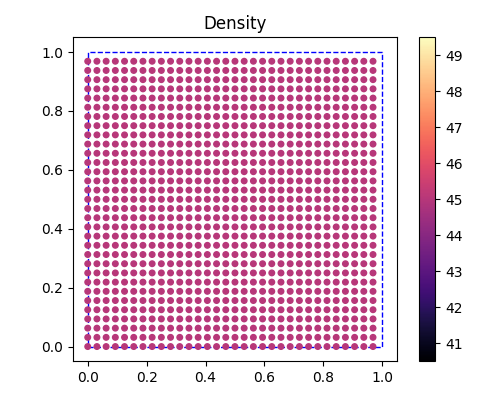

In [7]:
print('Number of neighbors:', numNeighbors.shape, numNeighbors)

fig, axis = plt.subplots(1,1 , figsize=(5,4), squeeze=False)
markerSize = 16
visualizeParticles(fig, axis[0,0], particleState, config['domain'], numNeighbors,
    kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'magma', markerSize = markerSize, gridVisualization = False, title = 'Density')

# plotDistribution(fig, axis[0,1], particleState, neighbors.get('noghost'), 63)
fig.tight_layout()


print(neighbors.neighbors.row.shape)

In [8]:
from layers.mlp import MLP, MLPConfig
from blocks.feedForwardNetwork import FeedForwardNetwork
from layers.tokenEncoder import TokenEncoderConfig, TokenEncoder
from layers.tokenMixer import printTensor
import copy
from layers.positionEncoder import BasisEncoder
from layers.mlp import MLPConfig

In [9]:
inputFeatures = values[0]
node_attr = (inputFeatures.unsqueeze(0), inputFeatures.unsqueeze(0))
node_positions = (particleState.positions.unsqueeze(0), particleState.positions.unsqueeze(0))

In [10]:
mlpConfig = MLPConfig(
        post_norm = True,
        norm_type = 'layer',
        hidden_dim = 32,
        hidden_layers = 2,
    )

In [11]:
bEnc = BasisEncoder(
    verbose = True,

    spatial_dim = 2,
    base_encoding = True,
    base_function = 'pfourier',
    base_terms = 11,
    base_mode = 'cat',

    projection = True,
    projection_linear = True,
    projection_dim = 7,
    projection_bias = False,

    mlpConfig = mlpConfig
).to(device)


#                       Initializing BasisEncoder Layer                        #
BasisEncoder: basis_terms=[11, 11], basis_function=['pfourier', 'pfourier'], mode=cat, spatial_dim=2
	BasisEncoder: basisShape=[22], total basis terms=22
	BasisEncoder: project_out=7, outputShape=7
BasisEncoder: basisShape=[22], total basis terms=22, outputShape=7
BasisEncoder: project_out=True, outputShape=7
BasisEncoder: projector=Linear(in_features=22, out_features=7, bias=False)
BasisEncoder Layer Initialized


In [12]:
apb_values = bEnc(node_positions[0])

#                          BasisEncoder Forward Pass                           #
	Input Positions shape: torch.Size([1, 1024, 2]), min: 0.0, max: 0.96875, mean: 0.484375, std: 0.28860461711883545
	Input Positions dim 0: min: 0.0, max: 0.96875, mean: 0.484375, std: 0.28867512941360474
	Input Positions dim 1: min: 0.0, max: 0.96875, mean: 0.484375, std: 0.28867512941360474
	Input Positions lengths: min: 0.0, max: 1.3700194358825684, mean: 0.7449491024017334, std: 0.28438013792037964
Input positions shape before shapeMatch: torch.Size([1, 1024, 2])
Input positions shape after shapeMatch: torch.Size([1024, 2]), batches=1, entries=1024, dim=2
--------------------------------------------------------------------------------
Tensor Input positions after shapeMatch: shape torch.Size([1024, 2]), dtype torch.float32, device cpu
	min: 0.0, max: 0.96875, mean: 0.484375, std: 0.28860461711883545
	Channel 0: min: 0.0, max: 0.96875, mean: 0.484375, std: 0.28867512941360474, data: 
	Channel 1: min: 0.0

In [13]:
rpb_values = bEnc(sparse_edge_attr)

#                          BasisEncoder Forward Pass                           #
	Input Positions shape: torch.Size([46080, 2]), min: -0.75, max: 0.75, mean: 0.0, std: 0.47140708565711975
	Input Positions dim 0: min: -0.75, max: 0.75, mean: 0.0, std: 0.4714096486568451
	Input Positions dim 1: min: -0.75, max: 0.75, mean: 0.0, std: 0.4714096486568451
	Input Positions lengths: min: 0.0, max: 0.9013878107070923, mean: 0.6277874708175659, std: 0.22434008121490479
Input positions shape before shapeMatch: torch.Size([46080, 2])
Input positions shape after shapeMatch: torch.Size([46080, 2]), batches=1, entries=46080, dim=2
--------------------------------------------------------------------------------
Tensor Input positions after shapeMatch: shape torch.Size([46080, 2]), dtype torch.float32, device cpu
	min: -0.75, max: 0.75, mean: 0.0, std: 0.47140708565711975
	Channel 0: min: -0.75, max: 0.75, mean: 0.0, std: 0.4714096486568451, data: 
	Channel 1: min: -0.75, max: 0.75, mean: 0.0, std: 0.4

In [14]:
from layers.tokenEncoder import TokenEncoderConfig, TokenEncoder
from layers.tokenMixer import printTensor
import copy
encodeConfig = TokenEncoderConfig()

display(encodeConfig)
# encodeConfig.projection_linear=True
# encodeConfig.token_output_dim = 11

inputEncoder = TokenEncoder(
    token_input_dim=node_attr[0].shape[-1], 
    token_output_dim=11,
    
    projection_linear = False,

    encodeConfig=encodeConfig, 
    mlpConfig=mlpConfig,
    verbose = True,
    verbosePrefix = "inputEncoder|").to(device)


TokenEncoderConfig(token_input_dim=0, token_output_dim=None, token_latent_dim=None, skip_connection=True, projection=True, projection_linear=True, position_bias=None, position_bias_mixing=None, position_bias_linear=True, position_bias_dim=None, use_ffn=False, ffn_linear=False, ffn_skip_connection=False, pre_norm=False, post_norm=False, final_activation=None)

#                  inputEncoder|Initializing Encode Layer...                   #
inputEncoder|	Token dimensions: input_token_dim=1, output_token_dim=11, latent_token_dim=11
inputEncoder|	Position bias encoding disabled
inputEncoder|	Input feature projection enabled [1 -> 11]
inputEncoder|	Using MLP for input feature projection
#                        inputEncoder|	Initializing MLP                        #
inputEncoder|	MLP init kwargs: {}
inputEncoder|	MLP init config: MLPConfig(input_dim=-1, output_dim=-1, batch_size=-1, seq_length=-1, hidden_dim=32, hidden_layers=2, activation='relu', initializer='uniform', dropout=0.0, gain=1.0, pre_norm=False, post_norm=True, hidden_norm=False, norm_type='layer', norm_affine=None, skip_linear=False, bias=False, residual=False)
inputEncoder|	MLP init in_features: 1, out_features: 11
inputEncoder|	MLP Configuration: MLPConfig(input_dim=1, output_dim=11, batch_size=-1, seq_length=-1, hidden_dim=32, hidden_layers=2, activation='relu', initializer='uni

In [15]:
encodedTokens = inputEncoder(
    inputTokens = node_attr[0],
    inputPositions = node_positions[0],
    encodedInputPositions = apb_values
)

printTensor('encodedTokens', encodedTokens)

#                        Running Input Encode Layer...                         #
inputEncoder|	Input tokens shape: torch.Size([1, 1024, 1])
inputEncoder|	Input positions shape: torch.Size([1, 1024, 2])
inputEncoder|	Projecting input features to latent space...
#                        inputEncoder|	MLP Forward Pass                        #
inputEncoder|	Input tensor shape: torch.Size([1024, 1])
inputEncoder|	Input tensor has no batch dimension, adding one
inputEncoder|	Input tensor shape after unsqueeze: torch.Size([1, 1024, 1])
inputEncoder|	Batch size: 1
inputEncoder|	Sequence length: 1024
inputEncoder|	Feature dimension: 1
inputEncoder|	Passing through hidden layers
inputEncoder|	Passing through final linear layer
inputEncoder|	Passing through post-norm layer
#              inputEncoder|	 [PostNorm] Norm Layer Forward Pass               #
inputEncoder|	 [PostNorm] Input tensor shape: torch.Size([1, 1024, 11])
inputEncoder|	 [PostNorm] Norm Layer output tensor shape: torch.Size([1, 1

In [16]:
in_features = encodedTokens.shape[-1]
out_features = 7

latentSpaceSize = 17
hiddenMLPSize = 61
hiddenMLPLayers = 2

inputEncoderLayers = 0
outputDecoderLayers = 0

transformerFeatures = 5
multiHeads = 4
batch_size = 1
num_nodes = inputFeatures.shape[0]
latentSpaceSize = 17
dim = particleState.positions.shape[-1]

stacked = encodedTokens
conditioningVector = torch.hstack([stacked.std(dim=1), stacked.max(dim=1).values, stacked.min(dim=1).values])
print(conditioningVector.shape)

torch.Size([1, 33])


In [17]:
from blocks.common import CommonConfiguration

mlpConfig = MLPConfig(
    hidden_dim = 32,
    hidden_layers = 2,
    hidden_norm = True,
    norm_type = 'layer',
    pre_norm=True,
    activation='gelu'
)

embeddingConfig = copy.deepcopy(mlpConfig)
embeddingConfig.hidden_dim = 16
embeddingConfig.hidden_layers = 3
embeddingConfig.input_dim = conditioningVector.shape[-1]

commonConfiguration = CommonConfiguration(
    token_input_dim=transformerFeatures * multiHeads,
    token_output_dim=transformerFeatures * multiHeads,
    spatial_dim=dim,
    edge_feature_dim=0,

    latent_features=transformerFeatures * multiHeads,
    hidden_layers=1,

    use_encoder=False,
    inputEncoderTokenConfig = None,

    use_decoder=False,
    outputDecoderTokenConfig = None,

    basis_function = 'ffourier',
    basis_terms = 6,
    basis_mode = 'cat',
    basis_projection = 'cartesian',

    mlpConfig = mlpConfig,
    embeddingConfig = embeddingConfig,
    use_conditioning=False
)


In [18]:
ffn = FeedForwardNetwork(
    in_features = in_features,
    out_features= out_features,
    config = commonConfiguration,
    verbose = True,
    verbosePrefix = 'FFN|')

#                     FFN|Initializing FeedForwardNetwork                      #
FFN|MLP Configuration: MLPConfig(input_dim=11, output_dim=7, batch_size=-1, seq_length=-1, hidden_dim=32, hidden_layers=2, activation='gelu', initializer='uniform', dropout=0.0, gain=1.0, pre_norm=True, post_norm=False, hidden_norm=True, norm_type='layer', norm_affine=None, skip_linear=False, bias=False, residual=False)
FFN|MLP Input Dim: 11
FFN|MLP Output Dim: 7
#                             FFN|Initializing MLP                             #
FFN|MLP init kwargs: {}
FFN|MLP init config: MLPConfig(input_dim=11, output_dim=7, batch_size=-1, seq_length=-1, hidden_dim=32, hidden_layers=2, activation='gelu', initializer='uniform', dropout=0.0, gain=1.0, pre_norm=True, post_norm=False, hidden_norm=True, norm_type='layer', norm_affine=None, skip_linear=False, bias=False, residual=False)
FFN|MLP init in_features: 11, out_features: 7
FFN|MLP Configuration: MLPConfig(input_dim=11, output_dim=7, batch_size=-1, seq_le

In [20]:
ffn(
    x = encodedTokens,
    embedding_input = conditioningVector
)

#                     FFN|FeedForwardNetwork Forward Pass                      #
FFN|Input tensor shape: torch.Size([1, 1024, 11])
FFN|Input tensor shape after unsqueeze: torch.Size([1, 1024, 11])
FFN|Batch size: 1
FFN|Sequence length: 1024
FFN|Feature dimension: 11
FFN|Ignoring embedding_input since no embedding MLP is used
FFN|Passing through pre-norm layer
FFN|Passing through main MLP
#                             FFN|MLP Forward Pass                             #
FFN|Input tensor shape: torch.Size([1, 1024, 11])
FFN|Input tensor shape after unsqueeze: torch.Size([1, 1024, 11])
FFN|Batch size: 1
FFN|Sequence length: 1024
FFN|Feature dimension: 11
FFN|Passing through pre-norm layer
#                    FFN| [PreNorm] Norm Layer Forward Pass                    #
FFN| [PreNorm] Input tensor shape: torch.Size([1, 1024, 11])
FFN| [PreNorm] Norm Layer output tensor shape: torch.Size([1, 1024, 11])
FFN| [PreNorm] Mean and std before norm: mean 7.789243028355486e-09, std 0.9461714625358582


tensor([[[-0.6692, -0.5902, -0.0905,  ..., -0.1090, -0.6254,  0.0761],
         [-0.6692, -0.5902, -0.0905,  ..., -0.1090, -0.6254,  0.0761],
         [-0.6692, -0.5902, -0.0905,  ..., -0.1090, -0.6254,  0.0761],
         ...,
         [-0.6692, -0.5902, -0.0905,  ..., -0.1090, -0.6254,  0.0761],
         [-0.6692, -0.5902, -0.0905,  ..., -0.1090, -0.6254,  0.0761],
         [-0.6692, -0.5902, -0.0905,  ..., -0.1090, -0.6254,  0.0761]]],
       grad_fn=<UnsafeViewBackward0>)

In [ ]:

encodedEdges = bEnc(sparse_edge_attr).detach()

inputFeatures = values[0]

inputFeatures = torch.sin(particleState.positions[:,0].view(-1,1)*2*np.pi)
# 
gt = values[0]**2
gt = inputFeatures**2

node_attr = (inputFeatures.unsqueeze(0), inputFeatures.unsqueeze(0))

token_j = encodedTokens[0,filteredNeighborhood.col]
stacked = torch.cat([token_j, encodedEdges], dim=-1)
printTensor('token_j', token_j)
printTensor('stacked', stacked)

SyntaxError: invalid syntax (2536641668.py, line 9)

In [ ]:


in_features = stacked.shape[-1]
out_features = 7

stacked.std(dim=0).unsqueeze(0)

mlpConfig = MLPConfig(
    hidden_dim = 32,
    hidden_layers = 2,
    hidden_norm = True,
    norm_type = 'layer',
    pre_norm=True,
    activation='gelu'
)

embeddingConfig = copy.deepcopy(mlpConfig)
embeddingConfig.hidden_dim = 16
embeddingConfig.hidden_layers = 3
embeddingConfig.input_dim = in_features

ffn = FeedForwardNetwork(
    in_features = in_features,
    out_features= out_features,
    config = mlpConfig,
    embeddingConfig = embeddingConfig,
    verbose = True,
    verbosePrefix = 'FFN|')

#                       Initializing BasisEncoder Layer                        #
BasisEncoder: basis_terms=[11, 11], basis_function=['pfourier', 'pfourier'], mode=cat, spatial_dim=2
	BasisEncoder: basisShape=[22], total basis terms=22
	BasisEncoder: project_out=7, outputShape=7
BasisEncoder: basisShape=[22], total basis terms=22, outputShape=7
BasisEncoder: project_out=True, outputShape=7
BasisEncoder: projector=Linear(in_features=22, out_features=7, bias=False)
BasisEncoder Layer Initialized
#                          BasisEncoder Forward Pass                           #
	Input Positions shape: torch.Size([46080, 2]), min: -0.75, max: 0.75, mean: 0.0, std: 0.47140708565711975
	Input Positions dim 0: min: -0.75, max: 0.75, mean: 0.0, std: 0.4714096486568451
	Input Positions dim 1: min: -0.75, max: 0.75, mean: 0.0, std: 0.4714096486568451
	Input Positions lengths: min: 0.0, max: 0.9013878107070923, mean: 0.6277874708175659, std: 0.22434008121490479
Input positions shape before shapeMatc

In [9]:
inputFeatures = values[0]

inputFeatures = torch.sin(particleState.positions[:,0].view(-1,1)*2*np.pi)
# 
gt = values[0]**2
gt = inputFeatures**2

node_attr = (inputFeatures.unsqueeze(0), inputFeatures.unsqueeze(0))

from layers.tokenEncoder import TokenEncoderConfig, TokenEncoder
from layers.tokenMixer import printTensor
import copy
encodeConfig = TokenEncoderConfig()

display(encodeConfig)
encodeConfig.projection_linear=True
encodeConfig.token_output_dim = 11

inputEncoder = TokenEncoder(1, encodeConfig, mlpConfig = mlpConfig).to(device)

encodedTokens = inputEncoder(inputFeatures.unsqueeze(0)).detach()

printTensor('encodedTokens', encodedTokens)

TokenEncoderConfig(token_input_dim=0, token_output_dim=None, token_latent_dim=None, skip_connection=True, projection=True, projection_linear=True, position_bias=None, position_bias_mixing=None, position_bias_linear=True, position_bias_dim=None, use_ffn=False, ffn_linear=False, ffn_skip_connection=False, pre_norm=False, post_norm=False, final_activation=None)

--------------------------------------------------------------------------------
Tensor encodedTokens: shape torch.Size([1, 1024, 11]), dtype torch.float32, device cpu
	min: -0.863093376159668, max: 0.863093376159668, mean: -1.3255472275375269e-09, std: 0.4278338849544525
	Channel 0: min: -0.863093376159668, max: 0.863093376159668, mean: 0.0, std: 0.6105973720550537, data: 
	Channel 1: min: -0.7455319166183472, max: 0.7455319166183472, mean: 3.632158041000366e-08, std: 0.5274282693862915, data: 
	Channel 2: min: -0.4776090383529663, max: 0.4776090383529663, mean: -1.5832483768463135e-08, std: 0.33788561820983887, data: 
	Channel 3: min: -0.14671671390533447, max: 0.14671671390533447, mean: 9.778887033462524e-09, std: 0.10379507392644882, data: 
	Channel 4: min: -0.38955438137054443, max: 0.38955438137054443, mean: 4.656612873077393e-10, std: 0.2755911350250244, data: 
	Channel 5: min: -0.8562240600585938, max: 0.8562240600585938, mean: -4.6566128730773926e-09, std: 0.6057376861572266, 

In [ ]:
token_j = encodedTokens[0,filteredNeighborhood.col]
printTensor('token_j', token_j)
stacked = torch.cat([token_j, encodedEdges], dim=-1)
printTensor('stacked', stacked)
from layers.mlp import MLP, MLPConfig
from blocks.feedForwardNetwork import FeedForwardNetwork

in_features = stacked.shape[-1]
out_features = 7

stacked.std(dim=0).unsqueeze(0)

mlpConfig = MLPConfig(
    hidden_dim = 32,
    hidden_layers = 2,
    hidden_norm = True,
    norm_type = 'layer',
    pre_norm=True,
    activation='gelu'
)

embeddingConfig = copy.deepcopy(mlpConfig)
embeddingConfig.hidden_dim = 16
embeddingConfig.hidden_layers = 3
embeddingConfig.input_dim = in_features

ffn = FeedForwardNetwork(
    in_features = in_features,
    out_features= out_features,
    config = mlpConfig,
    embeddingConfig = embeddingConfig,
    verbose = True,
    verbosePrefix = 'FFN|')

--------------------------------------------------------------------------------
Tensor token_j: shape torch.Size([46080, 11]), dtype torch.float32, device cpu
	min: -0.863093376159668, max: 0.863093376159668, mean: -8.428939768378996e-10, std: 0.4278152883052826
	Channel 0: min: -0.863093376159668, max: 0.863093376159668, mean: 0.0, std: 0.6103057861328125, data: 
	Channel 1: min: -0.7455319166183472, max: 0.7455319166183472, mean: 2.119276309997531e-08, std: 0.5271763801574707, data: 
	Channel 2: min: -0.4776090383529663, max: 0.4776090383529663, mean: -1.0596381549987655e-08, std: 0.3377242386341095, data: 
	Channel 3: min: -0.14671671390533447, max: 0.14671671390533447, mean: 5.298190774993827e-09, std: 0.10374551266431808, data: 
	Channel 4: min: -0.38955438137054443, max: 0.38955438137054443, mean: 0.0, std: 0.27545952796936035, data: 
	Channel 5: min: -0.8562240600585938, max: 0.8562240600585938, mean: 0.0, std: 0.6054484248161316, data: 
	Channel 6: min: -0.12594008445739746, m

In [ ]:
stacked = torch.cat([token_j, encodedEdges], dim=-1)
printTensor('stacked', stacked)
from layers.mlp import MLP, MLPConfig
from blocks.feedForwardNetwork import FeedForwardNetwork

in_features = stacked.shape[-1]
out_features = 7

stacked.std(dim=0).unsqueeze(0)

mlpConfig = MLPConfig(
    hidden_dim = 32,
    hidden_layers = 2,
    hidden_norm = True,
    norm_type = 'layer',
    pre_norm=True,
    activation='gelu'
)

embeddingConfig = copy.deepcopy(mlpConfig)
embeddingConfig.hidden_dim = 16
embeddingConfig.hidden_layers = 3
embeddingConfig.input_dim = in_features

ffn = FeedForwardNetwork(
    in_features = in_features,
    out_features= out_features,
    config = mlpConfig,
    embeddingConfig = embeddingConfig,
    verbose = True,
    verbosePrefix = 'FFN|')

--------------------------------------------------------------------------------
Tensor stacked: shape torch.Size([46080, 18]), dtype torch.float32, device cpu
	min: -1.8101273775100708, max: 1.2728095054626465, mean: -0.04873082786798477, std: 0.45714032649993896
	Channel 0: min: -0.863093376159668, max: 0.863093376159668, mean: 0.0, std: 0.6103057861328125, data: 
	Channel 1: min: -0.7455319166183472, max: 0.7455319166183472, mean: 2.119276309997531e-08, std: 0.5271763801574707, data: 
	Channel 2: min: -0.4776090383529663, max: 0.4776090383529663, mean: -1.0596381549987655e-08, std: 0.3377242386341095, data: 
	Channel 3: min: -0.14671671390533447, max: 0.14671671390533447, mean: 5.298190774993827e-09, std: 0.10374551266431808, data: 
	Channel 4: min: -0.38955438137054443, max: 0.38955438137054443, mean: 0.0, std: 0.27545952796936035, data: 
	Channel 5: min: -0.8562240600585938, max: 0.8562240600585938, mean: 0.0, std: 0.6054484248161316, data: 
	Channel 6: min: -0.12594008445739746, 

In [ ]:
from layers.mlp import MLP, MLPConfig
from blocks.feedForwardNetwork import FeedForwardNetwork

in_features = stacked.shape[-1]
out_features = 7

stacked.std(dim=0).unsqueeze(0)

mlpConfig = MLPConfig(
    hidden_dim = 32,
    hidden_layers = 2,
    hidden_norm = True,
    norm_type = 'layer',
    pre_norm=True,
    activation='gelu'
)

embeddingConfig = copy.deepcopy(mlpConfig)
embeddingConfig.hidden_dim = 16
embeddingConfig.hidden_layers = 3
embeddingConfig.input_dim = in_features

ffn = FeedForwardNetwork(
    in_features = in_features,
    out_features= out_features,
    config = mlpConfig,
    embeddingConfig = embeddingConfig,
    verbose = True,
    verbosePrefix = 'FFN|')

In [ ]:
in_features = stacked.shape[-1]
out_features = 7

stacked.std(dim=0).unsqueeze(0)

mlpConfig = MLPConfig(
    hidden_dim = 32,
    hidden_layers = 2,
    hidden_norm = True,
    norm_type = 'layer',
    pre_norm=True,
    activation='gelu'
)

embeddingConfig = copy.deepcopy(mlpConfig)
embeddingConfig.hidden_dim = 16
embeddingConfig.hidden_layers = 3
embeddingConfig.input_dim = in_features

ffn = FeedForwardNetwork(
    in_features = in_features,
    out_features= out_features,
    config = mlpConfig,
    embeddingConfig = embeddingConfig,
    verbose = True,
    verbosePrefix = 'FFN|')

In [ ]:
stacked.std(dim=0).unsqueeze(0)

mlpConfig = MLPConfig(
    hidden_dim = 32,
    hidden_layers = 2,
    hidden_norm = True,
    norm_type = 'layer',
    pre_norm=True,
    activation='gelu'
)

embeddingConfig = copy.deepcopy(mlpConfig)
embeddingConfig.hidden_dim = 16
embeddingConfig.hidden_layers = 3
embeddingConfig.input_dim = in_features

ffn = FeedForwardNetwork(
    in_features = in_features,
    out_features= out_features,
    config = mlpConfig,
    embeddingConfig = embeddingConfig,
    verbose = True,
    verbosePrefix = 'FFN|')

In [15]:
ffn = FeedForwardNetwork(
    in_features = in_features,
    out_features= out_features,
    config = mlpConfig,
    embeddingConfig = embeddingConfig,
    verbose = True,
    verbosePrefix = 'FFN|')

#                     FFN|Initializing FeedForwardNetwork                      #
FFN|MLP Configuration: MLPConfig(input_dim=18, output_dim=7, batch_size=-1, seq_length=-1, hidden_dim=32, hidden_layers=2, activation='gelu', initializer='uniform', dropout=0.0, gain=1.0, pre_norm=True, post_norm=False, hidden_norm=True, norm_type='layer', norm_affine=None, skip_linear=False, bias=False, residual=False)
FFN|MLP Input Dim: 18
FFN|MLP Output Dim: 7
#                             FFN|Initializing MLP                             #
FFN|MLP init kwargs: {}
FFN|MLP init config: MLPConfig(input_dim=18, output_dim=7, batch_size=-1, seq_length=-1, hidden_dim=32, hidden_layers=2, activation='gelu', initializer='uniform', dropout=0.0, gain=1.0, pre_norm=True, post_norm=False, hidden_norm=True, norm_type='layer', norm_affine=None, skip_linear=False, bias=False, residual=False)
FFN|MLP init in_features: 18, out_features: 7
FFN|MLP Configuration: MLPConfig(input_dim=18, output_dim=7, batch_size=-1, seq_le

In [16]:
stacked.shape

torch.Size([46080, 18])

In [17]:
out = ffn(stacked, stacked.std(dim=0).unsqueeze(0))
print(out.shape)


#                     FFN|FeedForwardNetwork Forward Pass                      #
FFN|Input tensor shape: torch.Size([46080, 18])
FFN|Input tensor has no batch dimension, adding one
FFN|Input tensor shape after unsqueeze: torch.Size([1, 46080, 18])
FFN|Batch size: 1
FFN|Sequence length: 46080
FFN|Feature dimension: 18
#                        FFN|Processing embedding input                        #
FFN|Passing through embedding MLP
#                       FFN|[Embedding] MLP Forward Pass                       #
FFN|[Embedding] Input tensor shape: torch.Size([1, 18])
FFN|[Embedding] Input tensor has no batch dimension, adding one
FFN|[Embedding] Input tensor shape after unsqueeze: torch.Size([1, 1, 18])
FFN|[Embedding] Batch size: 1
FFN|[Embedding] Sequence length: 1
FFN|[Embedding] Feature dimension: 18
FFN|[Embedding] Passing through pre-norm layer
#              FFN|[Embedding]  [PreNorm] Norm Layer Forward Pass              #
FFN|[Embedding]  [PreNorm] Input tensor shape: torch.Size([

In [18]:
conditioningMLP = MLP(
    in_features = in_features,
    out_features= in_features * 2 + out_features,

    config = mlpConfig,

    verbose = True,
).to(device)

conditioning = conditioningMLP(stacked.std(dim=0).unsqueeze(0))
print(conditioning.shape)

embeddings = [conditioning[:, :in_features],
              conditioning[:, in_features:in_features*2],
              conditioning[:, in_features*2:]]



#                               Initializing MLP                               #
MLP init kwargs: {}
MLP init config: MLPConfig(input_dim=-1, output_dim=-1, batch_size=-1, seq_length=-1, hidden_dim=32, hidden_layers=2, activation='gelu', initializer='uniform', dropout=0.0, gain=1.0, pre_norm=True, post_norm=False, hidden_norm=True, norm_type='layer', norm_affine=None, skip_linear=False, bias=False, residual=False)
MLP init in_features: 18, out_features: 43
MLP Configuration: MLPConfig(input_dim=18, output_dim=43, batch_size=-1, seq_length=-1, hidden_dim=32, hidden_layers=2, activation='gelu', initializer='uniform', dropout=0.0, gain=1.0, pre_norm=True, post_norm=False, hidden_norm=True, norm_type='layer', norm_affine=None, skip_linear=False, bias=False, residual=False)
MLP Input Dim: 18
MLP Output Dim: 43
Building MLP
Using activation: gelu
 [PreNorm] Building Norm Layer of type layer with channel_dim=18, batch_size=-1, seq_length=-1, affine=None
Using pre-norm: layer
No post-norm
Buil

In [19]:
mlp = MLP(
    in_features = in_features,
    out_features= out_features,

    seq_length = stacked.shape[0],


    hidden_dim = 32,
    hidden_layers = 2,
    hidden_norm = True,
    norm_type = 'layer',
    pre_norm = True,
    activation = 'silu',

    verbose = True,
).to(device)
print(mlp)

out = mlp(stacked.unsqueeze(0), embeddings[0], embeddings[1], embeddings[2])

#                               Initializing MLP                               #
MLP init kwargs: {'seq_length': 46080, 'hidden_dim': 32, 'hidden_layers': 2, 'hidden_norm': True, 'norm_type': 'layer', 'pre_norm': True, 'activation': 'silu'}
MLP init config: None
MLP init in_features: 18, out_features: 7
MLP Configuration: MLPConfig(input_dim=18, output_dim=7, batch_size=-1, seq_length=46080, hidden_dim=32, hidden_layers=2, activation='silu', initializer='uniform', dropout=0.0, gain=1.0, pre_norm=True, post_norm=False, hidden_norm=True, norm_type='layer', norm_affine=None, skip_linear=False, bias=False, residual=False)
MLP Input Dim: 18
MLP Output Dim: 7
Building MLP
Using activation: silu
 [PreNorm] Building Norm Layer of type layer with channel_dim=18, batch_size=-1, seq_length=46080, affine=None
Using pre-norm: layer
No post-norm
Building hidden layers
	Building hidden layer 1/2 with in_dim=18, out_dim=32
	Using hidden-norm: layer
 [HiddenNorm_Layer1] Building Norm Layer of type laye

In [20]:
latentSpaceSize = 17
hiddenMLPSize = 61
hiddenMLPLayers = 2

inputEncoderLayers = 0
outputDecoderLayers = 0

transformerFeatures = 5
multiHeads = 4
batch_size = 1
num_nodes = inputFeatures.shape[0]
latentSpaceSize = 17
dim = particleState.positions.shape[-1]

In [21]:
from blocks.common import CommonConfiguration
import copy

baseConfigNoEncoders = CommonConfiguration(
    token_input_dim=transformerFeatures * multiHeads,
    token_output_dim=transformerFeatures * multiHeads,
    spatial_dim=dim,
    edge_feature_dim=0,

    latent_features=transformerFeatures * multiHeads,
    hidden_layers=1,

    use_encoder=False,
    inputEncoderTokenConfig = None,

    use_decoder=False,
    outputDecoderTokenConfig = None,

    basis_function = 'ffourier',
    basis_terms = 6,
    basis_mode = 'cat',
    basis_projection = 'cartesian',

    # mlp_hidden_layers=2,
    # mlp_latent_dim = 32,
    # mlp_activation = 'silu',
)

baseConfig = copy.deepcopy(baseConfigNoEncoders)

from layers.tokenEncoder import TokenEncoderConfig
encodeConfig = TokenEncoderConfig()

display(encodeConfig)
encodeConfig.projection_linear=True

decodeConfig = copy.deepcopy(encodeConfig)
decodeConfig.projection_linear=True

TokenEncoderConfig(token_input_dim=0, token_output_dim=None, token_latent_dim=None, skip_connection=True, projection=True, projection_linear=True, position_bias=None, position_bias_mixing=None, position_bias_linear=True, position_bias_dim=None, use_ffn=False, ffn_linear=False, ffn_skip_connection=False, pre_norm=False, post_norm=False, final_activation=None)

In [23]:
from blocks.basicTransformer import BasicTransformer
from blocks.ContinuousConvolution import CConvModel, BasicCConvLayer
from models.GNN import GNNModel
from typing import Optional
import torch.nn as nn
from layers.mlp import MLPConfig, MLP
from blocks.encoder import BasicEncoder


def printTensor(name, tensor):
    print(''.join(['-']*80))
    print(f'Tensor {name}: shape {tensor.shape}, dtype {tensor.dtype}, device {tensor.device}')
    print(f'\tmin: {tensor.min().item()}, max: {tensor.max().item()}, mean: {tensor.mean().item()}, std: {tensor.std().item()}')
    # print(tensor)
    for i in range(tensor.shape[-1]):
        if len(tensor.shape) == 2:
            print(f'\tChannel {i}: min: {tensor[:,i].min().item()}, max: {tensor[:,i].max().item()}, mean: {tensor[:,i].mean().item()}, std: {tensor[:,i].std().item()}, data: ')
        else:
            print(f'\tChannel {i}: min: {tensor[:,:,i].min().item()}, max: {tensor[:,:,i].max().item()}, mean: {tensor[:,:,i].mean().item()}, std: {tensor[:,:,i].std().item()}, data: ')

    # for i in range(tensor.shape[-2]):
    #     print(f'\tParticle {i}: min: {tensor[:,i].min().item()}, max: {tensor[:,i].max().item()}, mean: {tensor[:,i].mean().item()}, std: {tensor[:,i].std().item()}, data: ')
    print(''.join(['-']*80))

class basicTest(nn.Module):
    def __init__(self, 
                 input_dim, output_dim,
                 transformer_features, multi_heads,
                 latent_dim, latent_layers,
                 encoderConfig, decoderConfig, commonConfig, 
                 numTransformers, mlpConfig: Optional[MLPConfig] = None, mode = 'transformer', verbose = False, verbosePrefix = ''):
        super(basicTest, self).__init__()
        self.inputEncoder = BasicEncoder(
            input_dim = input_dim,
            output_dim = transformer_features * multi_heads,
            hidden_layers = latent_layers,
            latent_dim = latent_dim,
            tokenEncoderConfig=encoderConfig,
                    mlpConfig= mlpConfig,
            verbose = verbose,
            verbosePrefix = verbosePrefix + 'InputEncoder|'
        )
        self.transformers = nn.ModuleList()
        for _ in range(numTransformers):
            if mode == 'transformer':
                transformer = BasicTransformer(
                    config = commonConfig,
                    transformer_features = transformer_features,
                    attention_heads = multi_heads,
                    mlpConfig= mlpConfig,

                    # attention_softmax = False,

                    verbose = verbose,
                    verbosePrefix = verbosePrefix + f'Transformer{_}|'
                )
            elif mode == 'cconv':
                transformer = CConvModel(
                    config=commonConfig,
                    mlpConfig= mlpConfig,

                    verbose = verbose,
                    verbosePrefix = verbosePrefix + f'CConv{_}|'
                )
            elif mode == 'gnn':
                transformer = GNNModel(
                    config = commonConfig,
                    mlpConfig= mlpConfig,

                    use_edge_mlp=True,
                    use_edge_encoder = True,
                    inputEdgeEncoderTokenConfig = None,
                    verbose = verbose,
                    verbosePrefix = verbosePrefix + f'GNN{_}|'
                )
            self.transformers.append(transformer)
        self.decoder = BasicEncoder(
            input_dim = transformer_features * multi_heads,
            output_dim = output_dim,
            hidden_layers = latent_layers,
            latent_dim = latent_dim,
            tokenEncoderConfig=decoderConfig,
                    mlpConfig= mlpConfig,
            verbose = verbose,
            verbosePrefix = verbosePrefix + 'Decoder|'
        )

    def forward(self, node_attr, edge_attr, edge_index, node_positions):
        # print('Input node_attr shape:', node_attr.shape)
        # printTensor('node_attr', node_attr)
        x = self.inputEncoder(node_attr, inputPositions = node_positions)
        # print('Encoded input shape:', x.shape)
        # printTensor('encoded node_attr', x)
        for i, transformer in enumerate(self.transformers):
            x = transformer(
                node_features = x,
                node_positions = node_positions[0],
                edge_indices = edge_index,
                edge_features = None,
                edge_spatial_features = edge_attr)
            # printTensor(f'after transformer {i}', x)
            # print('Transformed shape:', x.shape)
        out = self.decoder(x, inputPositions = node_positions)
        # print('Output shape:', out.shape)
        # printTensor('output', out)
        return out
    
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

multiHeads = 1
transformerFeatures = 11



baseConfigNoEncoders = CommonConfiguration(
    token_input_dim=transformerFeatures * multiHeads,
    token_output_dim=transformerFeatures * multiHeads,
    spatial_dim=dim,
    edge_feature_dim=0,

    latent_features=transformerFeatures * multiHeads,
    hidden_layers=1,

    use_encoder=False,
    inputEncoderTokenConfig = None,

    use_decoder=False,
    outputDecoderTokenConfig = None,

    basis_function = 'ffourier',
    basis_terms = 6,
    basis_mode = 'cat',
    basis_projection = 'cartesian',

    # mlp_hidden_layers=3,
    # mlp_latent_dim = 32,
    # mlp_activation = 'sigmoid',
)

mlpConfig = MLPConfig(
    post_norm = True,
    norm_type = 'layer',
    hidden_dim = 32,
    hidden_layers = 2,
)

basicModel = basicTest(
    input_dim = inputFeatures.shape[-1],
    output_dim = gt.shape[-1],
    transformer_features = transformerFeatures,
    multi_heads = multiHeads,
    latent_dim = 32,
    latent_layers = 1,
    encoderConfig = encodeConfig,
    decoderConfig = decodeConfig,
    commonConfig = baseConfigNoEncoders,
    numTransformers = 1,
    mlpConfig = mlpConfig,
    mode = 'gnn',
    verbose = True
).to(device)

InputEncoder|Initializing Basic Encoder...
#            InputEncoder|TokenEncoder|Initializing Encode Layer...            #
InputEncoder|TokenEncoder|	Token dimensions: input_token_dim=1, output_token_dim=11, latent_token_dim=11
InputEncoder|TokenEncoder|	Position bias encoding disabled
InputEncoder|TokenEncoder|	Input feature projection enabled [1 -> 11]
InputEncoder|TokenEncoder|	Using linear layer for input feature projection
InputEncoder|TokenEncoder|	Using skip connection from input to output
#       InputEncoder|TokenEncoder|Done initializing Input Encode Layer.        #
InputEncoder|	Token Encoder config: TokenEncoderConfig(token_input_dim=1, token_output_dim=11, token_latent_dim=11, skip_connection=True, projection=True, projection_linear=True, position_bias=None, position_bias_mixing=None, position_bias_linear=True, position_bias_dim=None, use_ffn=False, ffn_linear=False, ffn_skip_connection=False, pre_norm=False, post_norm=False, final_activation=None)
InputEncoder|	Number of

In [24]:
from layers.positionEncoder import BasisEncoder
bEnc = BasisEncoder(
    verbose = True,

    spatial_dim = 2,
    base_encoding = True,
    base_function = 'pfourier',
    base_terms = 11,
    base_mode = 'cat',

    projection = True,
    projection_linear = False,
    projection_dim = 7,
    projection_bias = False,
    mlpConfig = mlpConfig,
).to(device)





encodedEdges = bEnc(sparse_edge_attr).detach()

#                       Initializing BasisEncoder Layer                        #
BasisEncoder: basis_terms=[11, 11], basis_function=['pfourier', 'pfourier'], mode=cat, spatial_dim=2
	BasisEncoder: basisShape=[22], total basis terms=22
	BasisEncoder: project_out=7, outputShape=7
BasisEncoder: basisShape=[22], total basis terms=22, outputShape=7
BasisEncoder: project_out=True, outputShape=7
#                              	Initializing MLP                               #
	MLP init kwargs: {}
	MLP init config: MLPConfig(input_dim=-1, output_dim=-1, batch_size=-1, seq_length=-1, hidden_dim=32, hidden_layers=2, activation='relu', initializer='uniform', dropout=0.0, gain=1.0, pre_norm=False, post_norm=True, hidden_norm=False, norm_type='layer', norm_affine=None, skip_linear=False, bias=False, residual=False)
	MLP init in_features: 22, out_features: 7
	MLP Configuration: MLPConfig(input_dim=22, output_dim=7, batch_size=-1, seq_length=-1, hidden_dim=32, hidden_layers=2, activation='relu', initi

In [25]:
inputFeatures = values[0]

inputFeatures = torch.sin(particleState.positions[:,0].view(-1,1)*2*np.pi)
# 
gt = values[0]**2
gt = inputFeatures**2
# gt = values[1][:,0].view(-1,1)
# gt = torch.cos(particleState.positions[:,0].view(-1,1)*2*np.pi) * 2

# gt = 2 * particleState.positions[:,0].view(-1,1)

print(f'Input features: {inputFeatures.shape}, GT: {gt.shape}')
print(f'Input features statistics: max: {inputFeatures.max()}, min: {inputFeatures.min()}, mean: {inputFeatures.mean()}, std: {inputFeatures.std()}')
print(f'GT statistics: max: {gt.max()}, min: {gt.min()}, mean: {gt.mean()}, std: {gt.std()}')


neighbors, filteredNeighborhood, sparse_edge_attr, numNeighbors, neighborhood = prepNeighborhood(particleState, particleState, mode = config['supportScheme'], verletScale = config['neighborhood']['verletScale'], priorNeighborhood = None)

edge_attr = sparse_edge_attr
node_attr = (inputFeatures.unsqueeze(0), inputFeatures.unsqueeze(0))
edge_indices = torch.stack([filteredNeighborhood.row, filteredNeighborhood.col], dim=0)
node_positions = (particleState.positions.unsqueeze(0), particleState.positions.unsqueeze(0))


print(edge_indices.shape)

basicPred = basicModel(node_attr[0], edge_attr, edge_indices, node_positions[0]).squeeze(0)

print(f'Prediction shape: {basicPred.shape}')
print(f'Prediction statistics: max: {basicPred.max()}, min: {basicPred.min()}, mean: {basicPred.mean()}, std: {basicPred.std()}')

Input features: torch.Size([1024, 1]), GT: torch.Size([1024, 1])
Input features statistics: max: 1.0, min: -1.0, mean: -2.9802322387695312e-08, std: 0.7074522972106934
GT statistics: max: 1.0, min: 0.0, mean: 0.5, std: 0.3537261486053467
torch.Size([2, 46080])
#                        Running Input Encode Layer...                         #
InputEncoder|TokenEncoder|	Input tokens shape: torch.Size([1, 1024, 1])
InputEncoder|TokenEncoder|	Input positions shape: torch.Size([1, 1024, 2])
InputEncoder|TokenEncoder|	Projecting input features to latent space...
InputEncoder|TokenEncoder|	Encoded features shape: torch.Size([1024, 11])
InputEncoder|TokenEncoder|	InputEncoder|TokenEncoder|	Reshaping output to include batch dimension: 1
InputEncoder|TokenEncoder|	Output encoded features shape: torch.Size([1, 1024, 11])
InputEncoder|TokenEncoder|	Done running Input Encode Layer.
GNN0|GNN forward pass with 1 batches, 1024 nodes per batch, 11 features per node.
GNN0|	Edge indices shape: torch.Size([

In [25]:

basicModel = basicTest(
    input_dim = inputFeatures.shape[-1],
    output_dim = gt.shape[-1],
    transformer_features = transformerFeatures,
    multi_heads = multiHeads,
    latent_dim = 32,
    latent_layers = 1,
    encoderConfig = encodeConfig,
    decoderConfig = decodeConfig,
    transformerConfig = baseConfigNoEncoders,
    numTransformers = 1,
    mlpConfig = mlpConfig,
    mode = 'gnn'
).to(device)

optimizer = torch.optim.Adam(basicModel.parameters(), lr=1e-2)
numberOfParameters = count_parameters(basicModel)
print(f'Number of parameters in the model: {numberOfParameters}')



basicPred = basicModel(node_attr[0], edge_attr, edge_indices, node_positions[0]).squeeze(0)

print(basicPred)

GNN0|  L1|Message|		 [PostNorm] Building Norm Layer of type layer with channel_dim=11, batch_size=-1, seq_length=-1, affine=None
FFN|L1| [PostNorm] Building Norm Layer of type layer with channel_dim=11, batch_size=-1, seq_length=-1, affine=None
Number of parameters in the model: 4006
tensor([[-0.8374],
        [-0.8374],
        [-0.8374],
        ...,
        [-0.7889],
        [-0.7889],
        [-0.7889]], grad_fn=<SqueezeBackward1>)


In [64]:
inputFeatures = values[0]

# inputFeatures = torch.sin(particleState.positions[:,0].view(-1,1)*2*np.pi)
node_attr = (inputFeatures.unsqueeze(0), inputFeatures.unsqueeze(0))
# 
# gt = values[0]**2
gt = values[1][:,0].unsqueeze(-1)
# gt = torch.cos(particleState.positions[:,0].view(-1,1)*2*np.pi) * 2

In [66]:
losses_transformer2 = []
for i in (tq := tqdm(range(2**14), desc='Training', unit='epoch')) :
    optimizer.zero_grad()
    basicPred = basicModel(node_attr[0], edge_attr, edge_indices, node_positions[0]).squeeze(0)# * 100

    # print(basicPred.shape, gt.shape)
    # print(basicPred)
    fluidPred = basicPred#[particleState.kinds == 0]
    fluidGT = gt#[particleState.kinds == 0]

    if fluidPred.shape != fluidGT.shape:
        raise ValueError(f'Prediction shape {fluidPred.shape} does not match GT shape {fluidGT.shape}')

    # print(fluidPred.shape, fluidGT.shape)

    fluidLoss = torch.nn.functional.mse_loss(fluidPred, fluidGT)

    fluidLoss = ((fluidPred - fluidGT)**2).mean()
    # print('Fluid loss:', fluidLoss.item())

    # loss = torch.nn.functional.mse_loss(basicPred, gt)
    fluidLoss.backward()
    optimizer.step()
    tq.set_postfix({'loss': fluidLoss.item()})
    losses_transformer2.append(fluidLoss.item())

    # break

Training:   0%|          | 0/16384 [00:00<?, ?epoch/s]

KeyboardInterrupt: 

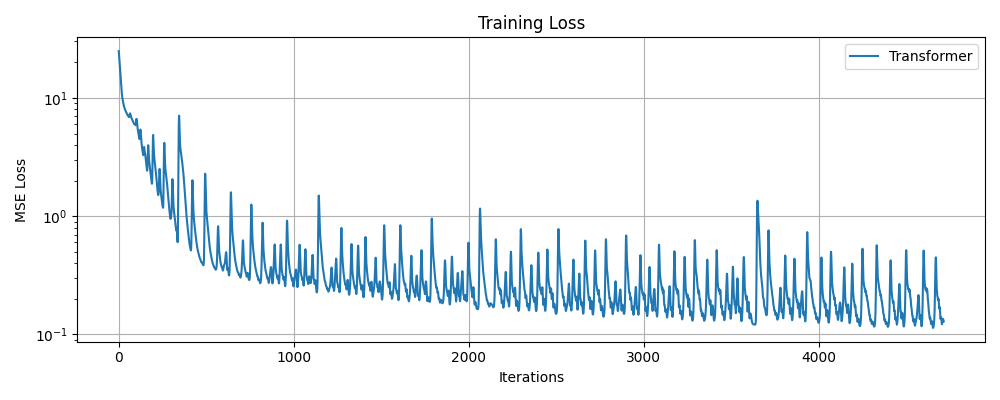

In [67]:
fig, axis = plt.subplots(1,1 , figsize=(10,4), squeeze=False)

# axis[0,0].plot(gaussian_filter1d(losses, sigma=16), label = 'GNN')
# axis[0,0].plot(gaussian_filter1d(losses_transformer, sigma=16), label = 'Transformer')
axis[0,0].plot(gaussian_filter1d(losses_transformer2, sigma=2), label = 'Transformer')
# axis[0,0].plot(gaussian_filter1d(losses_cconv, sigma=16), label = 'CConv')

axis[0,0].set_yscale('log')
axis[0,0].set_title('Training Loss')
axis[0,0].legend()

axis[0,0].grid(True)
axis[0,0].set_xlabel('Iterations')
axis[0,0].set_ylabel('MSE Loss')

fig.tight_layout()

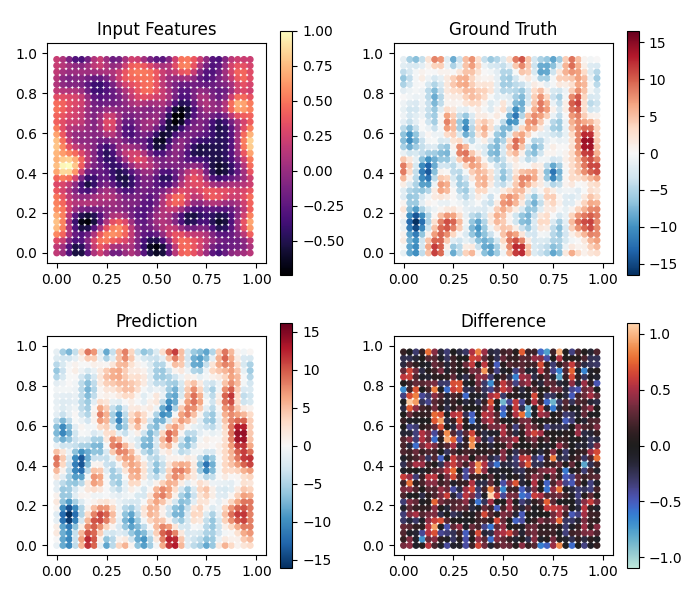

In [68]:
import seaborn as sns
fig, axis = plt.subplots(2,2, figsize=(7,6), squeeze=False)

markerSize = 16

plot = visualizeParticles(fig, axis[0, 0],
  particles = particleState,
  domain = domain,
  quantity = node_attr[0][0,:,0],
  which = 'fluid',
  mapping = '.x',
  cmap = 'magma',
  visualizeBoth=False,
  kernel = kernel,
  plotDomain = False,
  gridVisualization=False, markerSize=markerSize,
  streamLines = False)

gt_fluid = gt[:,0]

plot = visualizeParticles(fig, axis[0, 1],
  particles = particleState,
  domain = domain,
  quantity = gt_fluid,
  which = 'fluid',
  mapping = '.x',
  cmap = 'RdBu_r',
  visualizeBoth=False,
  kernel = kernel,
  plotDomain = False,
  gridVisualization=False, markerSize=markerSize,
  streamLines = False, vmax = gt_fluid.abs().max(), vmin = -gt_fluid.abs().max(),)

pred_fluid = basicPred[:,0].detach()
plot = visualizeParticles(fig, axis[1, 0],
  particles = particleState,
  domain = domain,
  quantity = pred_fluid,
  which = 'fluid',
  mapping = '.x',
  cmap = 'RdBu_r',
  visualizeBoth=False,
  kernel = kernel,
  plotDomain = False,
  gridVisualization=False, markerSize=markerSize,
  streamLines = False,
  vmax = pred_fluid.abs().max(), vmin = -pred_fluid.abs().max(),
  )

diff = (basicPred[:,0] - gt[:,0]).detach()
plot = visualizeParticles(fig, axis[1, 1],
  particles = particleState,
  domain = domain,
  quantity = diff,
  which = 'fluid',
  mapping = '.x',
  cmap = 'icefire',
  visualizeBoth=False,
  kernel = kernel,
  plotDomain = False,
  gridVisualization=False, markerSize=  markerSize,
  streamLines = False,
  vmax = diff.abs().max(), vmin = -diff.abs().max(),
  )

axis[0,0].set_title('Input Features')
axis[0,1].set_title('Ground Truth')
axis[1,0].set_title('Prediction')
axis[1,1].set_title('Difference')

fig.tight_layout()

# display(fig)

In [39]:
diff.mean()

tensor(0.2913)